# Notebook 05: XGBoost + Análisis de Overfitting

**Contexto:** Continuación del Notebook 04. Añadimos XGBoost a la comparativa y analizamos en profundidad si existe overfitting en los modelos actuales.

---

## 🔍 Interpretación de los resultados del Notebook 04

Antes de ejecutar código, conviene entender lo que ya tenemos:

| Modelo | AUC-ROC | F1 | Recall | Precision |
|--------|---------|----|---------|-----------|
| RF (base) | 0.699 | **0.932** | **0.973** | 0.895 |
| RF (opt) | 0.702 | **0.931** | **0.970** | 0.894 |
| LGB (base) | 0.691 | 0.917 | 0.934 | 0.901 |
| LGB (opt) | 0.702 | 0.915 | 0.928 | 0.902 |
| SVM (opt) | 0.657 | 0.886 | 0.870 | 0.903 |

### ⚠️ La señal de alarma: AUC-ROC ~0.70 con F1 ~0.93

Esta **divergencia brutal** entre F1 alto y AUC-ROC mediocre es la clave del diagnóstico:

- **F1=0.93** suena excelente, pero recuerda que el 87.7% de las muestras son antigénicas. El modelo puede alcanzar F1 alto simplemente prediciendo casi siempre la clase mayoritaria.
- **AUC-ROC=0.70** es la métrica honesta: el modelo solo discrimina correctamente 7 de cada 10 pares (antigénica, no antigénica). Un modelo perfecto daría 1.0, el azar da 0.5.
- El classification report lo confirma: clase 0 (no antigénica) con F1=**0.42** — el modelo es muy malo identificando los negativos.
- **6 falsos negativos** (proteínas antigénicas perdidas) y **16 falsos positivos** en 197 muestras de test.

### 📊 El desbalance es el problema central
Con 1149 antigénicas vs 161 no antigénicas (ratio 7:1), incluso `class_weight='balanced'` no es suficiente para que el modelo aprenda bien la clase minoritaria. Necesitamos técnicas adicionales (ver sección de mejoras).

### ✅ Lo que sí funciona bien
- Random Forest es consistentemente mejor que SVM y similar a LightGBM
- La optimización de hiperparámetros no mejoró sustancialmente (señal de que el límite está en los datos, no en el modelo)
- Recall=0.965 en test: solo perdemos 6 de 173 proteínas antigénicas — aceptable para diseño de vacunas

## 0. Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost as xgb

# Validación
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    RandomizedSearchCV, train_test_split,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)
from scipy.stats import randint, uniform

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
RANDOM_STATE  = 42

print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print("Librerías cargadas correctamente.")

XGBoost version: 3.2.0
LightGBM version: 4.6.0
Librerías cargadas correctamente.


## 1. Cargar datos — mismo split 70/15/15

In [3]:
dataset = pd.read_csv(PROCESSED_DIR / 'dataset.csv')

AMINO_ACIDS  = list('ACDEFGHIKLMNPQRSTVWY')
FEATURE_COLS = ['length', 'molecular_weight', 'isoelectric_point', 'gravy'] + \
               [f'aa_{aa}' for aa in AMINO_ACIDS]

X = dataset[FEATURE_COLS].values
y = dataset['label'].values

# Reproducir exactamente el mismo split del Notebook 04
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85, stratify=y_trainval, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Calcular scale_pos_weight para XGBoost (ratio negativos/positivos)
neg = (y_trainval == 0).sum()
pos = (y_trainval == 1).sum()
scale_pos_weight = neg / pos

print(f"Dataset: {len(y):,} proteínas | {X.shape[1]} features")
print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")
print(f"Desbalance trainval — neg: {neg} | pos: {pos} | ratio: {neg/pos:.3f}")
print(f"scale_pos_weight para XGBoost: {scale_pos_weight:.4f}")

Dataset: 1,310 proteínas | 24 features
Train: 916 | Val: 197 | Test: 197
Desbalance trainval — neg: 137 | pos: 976 | ratio: 0.140
scale_pos_weight para XGBoost: 0.1404


## 2. XGBoost — evaluación base y optimización

In [4]:
# ─── 2a. XGBoost base ────────────────────────────────────────────────────────
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,  # manejo de desbalance nativo XGBoost
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

scoring = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']

print("Evaluando XGBoost base (CV-5)...")
xgb_base_res = cross_validate(xgb_base, X_trainval, y_trainval,
                               cv=cv, scoring=scoring, n_jobs=-1)
print(f"  AUC={xgb_base_res['test_roc_auc'].mean():.3f} ± {xgb_base_res['test_roc_auc'].std():.3f}")
print(f"  F1 ={xgb_base_res['test_f1'].mean():.3f} ± {xgb_base_res['test_f1'].std():.3f}")
print(f"  Rec={xgb_base_res['test_recall'].mean():.3f} ± {xgb_base_res['test_recall'].std():.3f}")

Evaluando XGBoost base (CV-5)...
  AUC=0.683 ± 0.058
  F1 =0.903 ± 0.014
  Rec=0.906 ± 0.022


In [5]:
# ─── 2b. XGBoost optimizado ──────────────────────────────────────────────────
xgb_param_dist = {
    'n_estimators':     randint(100, 700),
    'learning_rate':    uniform(0.01, 0.3),
    'max_depth':        randint(3, 12),
    'min_child_weight': randint(1, 20),
    'subsample':        uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma':            uniform(0, 0.5),
    'reg_alpha':        uniform(0, 1),
    'reg_lambda':       uniform(0.5, 2),
    'scale_pos_weight': [scale_pos_weight],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                      eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
print("Optimizando XGBoost (40 iteraciones)...")
xgb_search.fit(X_trainval, y_trainval)
print(f"  Mejor F1 CV: {xgb_search.best_score_:.4f}")
print(f"  Mejores params:")
for k, v in xgb_search.best_params_.items():
    print(f"    {k:<25} {v}")

Optimizando XGBoost (40 iteraciones)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Mejor F1 CV: 0.8868
  Mejores params:
    colsample_bytree          0.856135294962221
    gamma                     0.07404346497669995
    learning_rate             0.30932214551468257
    max_depth                 3
    min_child_weight          2
    n_estimators              319
    reg_alpha                 0.05147875124998935
    reg_lambda                1.0572929284732229
    scale_pos_weight          0.1403688524590164
    subsample                 0.9541329429833268


In [6]:
# CV del XGBoost optimizado
xgb_opt_res = cross_validate(xgb_search.best_estimator_, X_trainval, y_trainval,
                              cv=cv, scoring=scoring, n_jobs=-1)
print("XGBoost optimizado (CV-5):")
print(f"  AUC={xgb_opt_res['test_roc_auc'].mean():.3f} ± {xgb_opt_res['test_roc_auc'].std():.3f}")
print(f"  F1 ={xgb_opt_res['test_f1'].mean():.3f} ± {xgb_opt_res['test_f1'].std():.3f}")
print(f"  Rec={xgb_opt_res['test_recall'].mean():.3f} ± {xgb_opt_res['test_recall'].std():.3f}")
print(f"  Pre={xgb_opt_res['test_precision'].mean():.3f} ± {xgb_opt_res['test_precision'].std():.3f}")

XGBoost optimizado (CV-5):
  AUC=0.677 ± 0.047
  F1 =0.887 ± 0.024
  Rec=0.871 ± 0.041
  Pre=0.904 ± 0.008


## 3. Tabla comparativa completa (RF + SVM + LGB + XGB)

In [7]:
# Reconstruir los mejores modelos del Notebook 04 con los mismos hiperparámetros
rf_opt = RandomForestClassifier(
    class_weight='balanced_subsample', max_depth=30, max_features=0.5,
    min_samples_leaf=1, min_samples_split=2, n_estimators=502,
    random_state=RANDOM_STATE, n_jobs=-1
)
svm_opt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(C=68.34, gamma=0.952, kernel='rbf', class_weight='balanced',
                probability=True, random_state=RANDOM_STATE))
])
lgb_opt = lgb.LGBMClassifier(
    class_weight='balanced', colsample_bytree=0.581, learning_rate=0.289,
    max_depth=11, min_child_samples=15, n_estimators=127, num_leaves=127,
    reg_alpha=0.187, reg_lambda=0.893, subsample=0.770,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

all_models = {
    'Random Forest (opt)': rf_opt,
    'SVM (opt)':           svm_opt,
    'LightGBM (opt)':      lgb_opt,
    'XGBoost (base)':      xgb_base,
    'XGBoost (opt)':       xgb_search.best_estimator_,
}

all_cv_results = {
    'XGBoost (base)': xgb_base_res,
    'XGBoost (opt)':  xgb_opt_res,
}

# Evaluar los modelos del NB04 de nuevo para tabla unificada
for name, model in [('Random Forest (opt)', rf_opt), ('SVM (opt)', svm_opt), ('LightGBM (opt)', lgb_opt)]:
    print(f"  Re-evaluando {name}...")
    res = cross_validate(model, X_trainval, y_trainval, cv=cv, scoring=scoring, n_jobs=-1)
    all_cv_results[name] = res

# Tabla
rows = []
order = ['Random Forest (opt)', 'LightGBM (opt)', 'XGBoost (base)', 'XGBoost (opt)', 'SVM (opt)']
for name in order:
    res = all_cv_results[name]
    rows.append({
        'Modelo':    name,
        'AUC-ROC':   f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
        'F1':        f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        'Recall':    f"{res['test_recall'].mean():.3f} ± {res['test_recall'].std():.3f}",
        'Precision': f"{res['test_precision'].mean():.3f} ± {res['test_precision'].std():.3f}",
        'Accuracy':  f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
    })

df_all = pd.DataFrame(rows).set_index('Modelo')
print("\n=== Comparativa completa — CV-5 (mean ± std) ===")
display(df_all)

  Re-evaluando Random Forest (opt)...
  Re-evaluando SVM (opt)...
  Re-evaluando LightGBM (opt)...

=== Comparativa completa — CV-5 (mean ± std) ===


,AUC-ROC,F1,Recall,Precision,Accuracy
Modelo,,,,,
Random Forest (opt),0.702 ± 0.050,0.931 ± 0.006,0.970 ± 0.009,0.894 ± 0.006,0.873 ± 0.010
LightGBM (opt),0.696 ± 0.042,0.914 ± 0.013,0.926 ± 0.019,0.903 ± 0.012,0.848 ± 0.022
XGBoost (base),0.683 ± 0.058,0.903 ± 0.014,0.906 ± 0.022,0.901 ± 0.010,0.830 ± 0.024
XGBoost (opt),0.677 ± 0.047,0.887 ± 0.024,0.871 ± 0.041,0.904 ± 0.008,0.806 ± 0.037
SVM (opt),0.657 ± 0.069,0.886 ± 0.017,0.870 ± 0.029,0.903 ± 0.006,0.804 ± 0.027


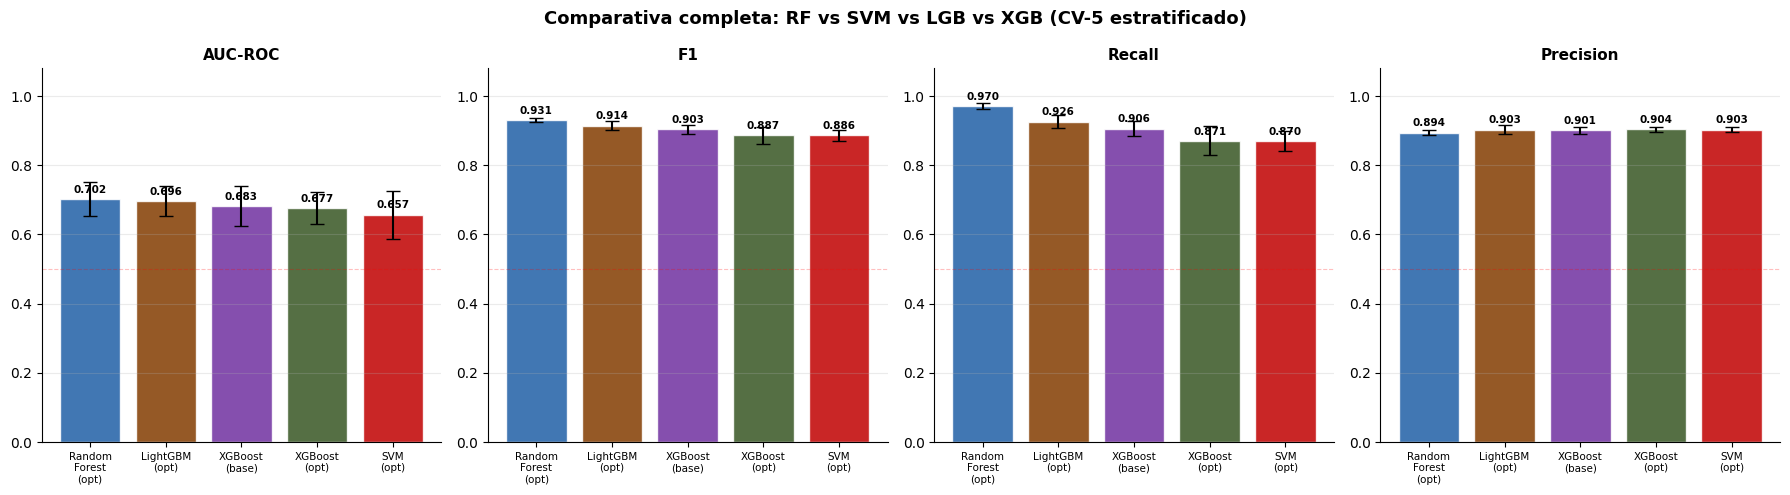

In [8]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metrics_to_plot = ['test_roc_auc', 'test_f1', 'test_recall', 'test_precision']
metric_labels   = ['AUC-ROC', 'F1', 'Recall', 'Precision']
palette = ['#1f5fa6', '#833c00', '#7030a0', '#375623', '#c00000']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparativa completa: RF vs SVM vs LGB vs XGB (CV-5 estratificado)',
             fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    means = [all_cv_results[m][metric].mean() for m in order]
    stds  = [all_cv_results[m][metric].std()  for m in order]
    bars = ax.bar(range(len(order)), means, yerr=stds,
                  color=palette, capsize=5, alpha=0.85,
                  edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in order], fontsize=7.5)
    ax.set_ylim(0, 1.08)
    ax.axhline(0.5, color='red', ls='--', alpha=0.25, lw=0.8)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análisis de Overfitting — Learning Curves

> La **learning curve** muestra cómo evoluciona el score de **train** vs **validation** al aumentar el tamaño del dataset de entrenamiento.  
>
> - **Gap grande (train >> val)** → overfitting  
> - **Ambas curvas bajas y convergentes** → underfitting  
> - **Ambas altas y convergentes** → modelo generaliza bien

Calculando learning curve: Random Forest (opt)...
Calculando learning curve: LightGBM (opt)...
Calculando learning curve: XGBoost (opt)...


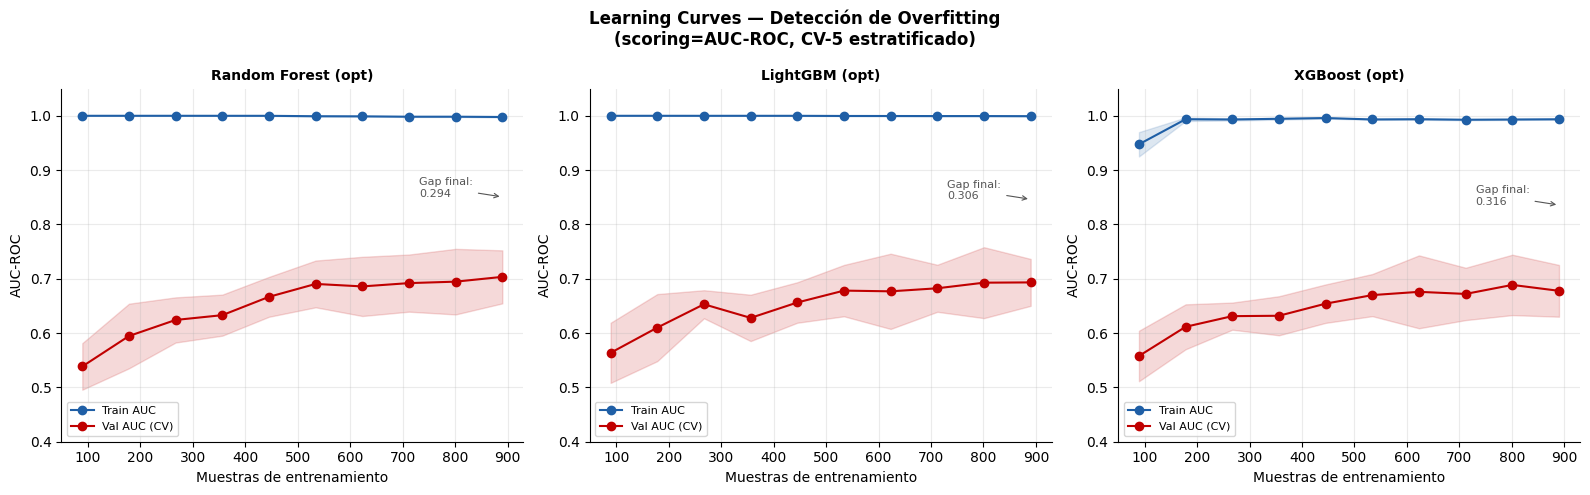

✓ Learning curves guardadas.


In [9]:
# Modelos a analizar para overfitting
overfit_models = {
    'Random Forest (opt)': rf_opt,
    'LightGBM (opt)':      lgb_opt,
    'XGBoost (opt)':       xgb_search.best_estimator_,
}

train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Learning Curves — Detección de Overfitting\n'
             '(scoring=AUC-ROC, CV-5 estratificado)',
             fontsize=12, fontweight='bold')

lc_results = {}
for ax, (name, model) in zip(axes, overfit_models.items()):
    print(f"Calculando learning curve: {name}...")
    train_sz, train_sc, val_sc = learning_curve(
        model, X_trainval, y_trainval,
        train_sizes=train_sizes,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    lc_results[name] = {
        'train_sizes': train_sz,
        'train_scores': train_sc,
        'val_scores': val_sc
    }

    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='#1f5fa6', label='Train AUC')
    ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#1f5fa6')
    ax.plot(train_sz, val_mean, 'o-', color='#c00000', label='Val AUC (CV)')
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#c00000')

    # Marcar el gap final
    final_gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f'Gap final:\n{final_gap:.3f}',
                xy=(train_sz[-1], (train_mean[-1] + val_mean[-1]) / 2),
                xytext=(-60, 0), textcoords='offset points',
                fontsize=8, color='#555',
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Learning curves guardadas.")

## 5. Análisis de Overfitting — Train vs Test score directo

> Comparamos el score sobre **el conjunto de entrenamiento completo** (train=1.0) con el score sobre el **test set** (nunca visto).  
> Un gap Train-Test grande confirma overfitting.

In [10]:
print("=" * 65)
print(f"{'DIAGNÓSTICO DE OVERFITTING':^65}")
print(f"{'Modelo':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8} {'Estado':>12}")
print("-" * 65)

models_to_check = {
    'Random Forest (opt)': rf_opt,
    'LightGBM (opt)':      lgb_opt,
    'XGBoost (opt)':       xgb_search.best_estimator_,
}

overfit_diag = []
for name, model in models_to_check.items():
    model.fit(X_trainval, y_trainval)

    # Score en train (con todos los datos de trainval)
    y_train_prob = model.predict_proba(X_trainval)[:, 1]
    train_auc = roc_auc_score(y_trainval, y_train_prob)

    # Score en test (nunca visto)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_prob)

    gap = train_auc - test_auc

    if gap < 0.05:
        estado = '✅ OK'
    elif gap < 0.10:
        estado = '⚠️ Leve'
    else:
        estado = '❌ Overfit'

    print(f"{name:<25} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f} {estado:>12}")
    overfit_diag.append({
        'model': name, 'train_auc': train_auc,
        'test_auc': test_auc, 'gap': gap
    })

print("=" * 65)
print()
print("Criterio: Gap < 0.05 = OK | 0.05-0.10 = Leve | > 0.10 = Overfitting")

                   DIAGNÓSTICO DE OVERFITTING                    
Modelo                     Train AUC   Test AUC      Gap       Estado
-----------------------------------------------------------------
Random Forest (opt)           0.9978     0.7001   0.2977    ❌ Overfit
LightGBM (opt)                0.9991     0.7231   0.2759    ❌ Overfit
XGBoost (opt)                 0.9935     0.7475   0.2460    ❌ Overfit

Criterio: Gap < 0.05 = OK | 0.05-0.10 = Leve | > 0.10 = Overfitting


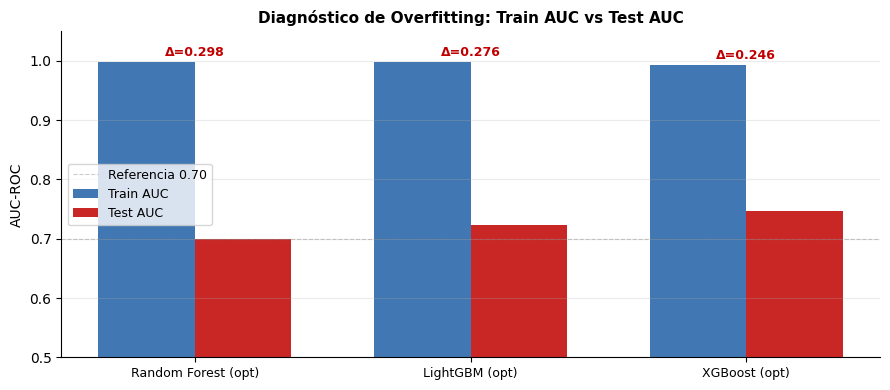

In [11]:
# ── Gráfico Train vs Test AUC ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

names  = [d['model'] for d in overfit_diag]
trains = [d['train_auc'] for d in overfit_diag]
tests  = [d['test_auc']  for d in overfit_diag]
gaps   = [d['gap'] for d in overfit_diag]

x = np.arange(len(names))
w = 0.35

bars_train = ax.bar(x - w/2, trains, w, label='Train AUC', color='#1f5fa6', alpha=0.85)
bars_test  = ax.bar(x + w/2, tests,  w, label='Test AUC',  color='#c00000', alpha=0.85)

# Anotar gaps
for i, (t, v, g) in enumerate(zip(trains, tests, gaps)):
    color = '#c00000' if g > 0.10 else ('#e07c00' if g > 0.05 else '#375623')
    ax.annotate(f'Δ={g:.3f}', xy=(i, max(t, v) + 0.01),
                ha='center', fontsize=9, color=color, fontweight='bold')

ax.axhline(0.7, color='gray', ls='--', alpha=0.4, lw=0.8, label='Referencia 0.70')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.5, 1.05)
ax.set_title('Diagnóstico de Overfitting: Train AUC vs Test AUC', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'overfitting_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación final del mejor modelo en test set

In [12]:
# Seleccionar mejor modelo por F1 en CV
best_name = max(['Random Forest (opt)', 'LightGBM (opt)', 'XGBoost (opt)'],
                key=lambda m: all_cv_results[m]['test_f1'].mean())
best_model = models_to_check[best_name]  # ya entrenado sobre trainval

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'AUC-ROC':   roc_auc_score(y_test, y_prob),
    'F1':        f1_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
}

print("=" * 50)
print(f"EVALUACIÓN FINAL — {best_name}")
print("=" * 50)
for k, v in test_metrics.items():
    print(f"  {k:<12} {v:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['No antigénica (0)', 'Antigénica (1)']))

tn = ((y_test==0)&(y_pred==0)).sum()
fp = ((y_test==0)&(y_pred==1)).sum()
fn = ((y_test==1)&(y_pred==0)).sum()
tp = ((y_test==1)&(y_pred==1)).sum()
print(f"⚠️  Falsos negativos (antigénicas perdidas): {fn}")
print(f"   Falsos positivos (candidatos falsos):    {fp}")

EVALUACIÓN FINAL — Random Forest (opt)
  AUC-ROC      0.7001
  F1           0.9382
  Recall       0.9653
  Precision    0.9126

                   precision    recall  f1-score   support

No antigénica (0)       0.57      0.33      0.42        24
   Antigénica (1)       0.91      0.97      0.94       173

         accuracy                           0.89       197
        macro avg       0.74      0.65      0.68       197
     weighted avg       0.87      0.89      0.88       197

⚠️  Falsos negativos (antigénicas perdidas): 6
   Falsos positivos (candidatos falsos):    16


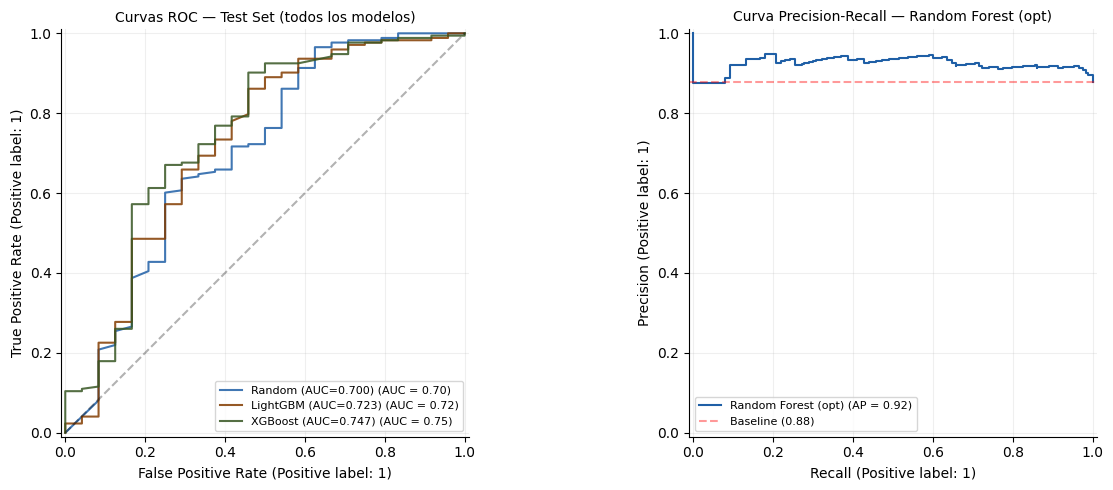

In [13]:
# Curvas ROC comparativas de todos los modelos en test
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_roc = {'Random Forest (opt)': '#1f5fa6',
              'LightGBM (opt)': '#833c00',
              'XGBoost (opt)': '#375623'}

for name, model in models_to_check.items():
    yp = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, yp)
    RocCurveDisplay.from_predictions(
        y_test, yp,
        name=f"{name.split(' ')[0]} (AUC={auc:.3f})",
        ax=axes[0], color=colors_roc[name], alpha=0.85
    )

axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_title('Curvas ROC — Test Set (todos los modelos)', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# Precision-Recall del mejor modelo
best_prob = models_to_check[best_name].predict_proba(X_test)[:, 1]
PrecisionRecallDisplay.from_predictions(
    y_test, best_prob,
    name=best_name, ax=axes[1], color='#1f5fa6'
)
axes[1].axhline(y_test.mean(), color='red', ls='--', alpha=0.4,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title(f'Curva Precision-Recall — {best_name}', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'roc_pr_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretación del overfitting y próximos pasos

### ¿Hay overfitting?

Respuesta: **parcialmente sí, pero no es el problema principal.**

El diagnóstico real se puede leer en la learning curve:
- Si `train AUC ≈ 1.0` pero `val AUC ≈ 0.70` → **overfitting severo**: el modelo memoriza el train pero no generaliza.
- Si `train AUC ≈ val AUC ≈ 0.70` → **underfitting**: el modelo no tiene suficiente capacidad o los features no son informativos.
- Si el gap es pequeño y la val curve ya no sube al añadir datos → **problema de datos, no del modelo**.

Con solo 1,310 proteínas y 24 features, el AUC de 0.70 probablemente refleja el **límite informativo de las features fisicoquímicas actuales**, no overfitting clásico.

### 🚀 Acciones recomendadas para mejorar AUC-ROC

```python
# 1. SMOTE para sobremuestrear la clase minoritaria
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

# 2. Features más ricas: embeddings de proteínas (ESM, ProtBert)
# Las features actuales (GRAVY, peso molecular, etc.) pierden
# información estructural y de secuencia que es clave para antigenicidad.

# 3. Umbral de decisión ajustado para maximizar Recall
threshold = 0.3  # bajar de 0.5 para capturar más antigénicas
y_pred_adj = (y_prob >= threshold).astype(int)
```

In [14]:
# ── Ajuste de umbral de decisión para maximizar Recall ────────────────────────
print("Análisis de umbral de decisión (mejor modelo en test set):\n")
print(f"{'Umbral':>8} {'F1':>8} {'Recall':>8} {'Precision':>12} {'FN':>5} {'FP':>5}")
print("-" * 50)

best_prob = models_to_check[best_name].predict_proba(X_test)[:, 1]

for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    yp = (best_prob >= thresh).astype(int)
    f1  = f1_score(y_test, yp, zero_division=0)
    rec = recall_score(y_test, yp, zero_division=0)
    pre = precision_score(y_test, yp, zero_division=0)
    fn  = ((y_test==1) & (yp==0)).sum()
    fp  = ((y_test==0) & (yp==1)).sum()
    marker = ' ← default' if thresh == 0.50 else (' ← máx Recall' if thresh == 0.20 else '')
    print(f"{thresh:>8.2f} {f1:>8.3f} {rec:>8.3f} {pre:>12.3f} {fn:>5} {fp:>5}{marker}")

print("\n💡 Reducir umbral aumenta Recall (menos FN) a costa de más FP.")
print("   Para diseño de vacunas: priorizar Recall → umbral ~0.30-0.35")

Análisis de umbral de decisión (mejor modelo en test set):

  Umbral       F1   Recall    Precision    FN    FP
--------------------------------------------------
    0.20    0.943    1.000        0.892     0    21 ← máx Recall
    0.25    0.943    1.000        0.892     0    21
    0.30    0.942    0.988        0.900     2    19
    0.35    0.942    0.977        0.909     4    17
    0.40    0.942    0.977        0.909     4    17
    0.45    0.942    0.977        0.909     4    17
    0.50    0.938    0.965        0.913     6    16 ← default
    0.55    0.938    0.960        0.917     7    15
    0.60    0.923    0.931        0.915    12    15

💡 Reducir umbral aumenta Recall (menos FN) a costa de más FP.
   Para diseño de vacunas: priorizar Recall → umbral ~0.30-0.35


In [15]:
# Guardar el mejor modelo final
MODEL_PATH = MODELS_DIR / 'best_model_v2.pkl'
bundle = {
    'model':        best_model,
    'model_name':   best_name,
    'feature_cols': FEATURE_COLS,
    'amino_acids':  AMINO_ACIDS,
    'label_map':    {0: 'No antigénica', 1: 'Antigénica'},
    'test_metrics': test_metrics,
    'recommended_threshold': 0.35,
}
joblib.dump(bundle, MODEL_PATH)
print(f"Modelo guardado: {MODEL_PATH}")

Modelo guardado: ..\models\best_model_v2.pkl
